![](https://www.dii.uchile.cl/wp-content/uploads/2021/06/Magi%CC%81ster-en-Ciencia-de-Datos.png)

**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

### 👨‍🏫👩‍🏫 Cuerpo Docente:

- Profesor: Pablo Badilla, Diego Cortez
- Auxiliar: Melanie Peña Torres, Valentina Rojas Osorio
- Ayudante: Javiera Arévalo, Tamara Carrasco, Ignacio Reyes

### 👨‍💻👩‍💻 Estudiantes:
- Estudiante n°1: Álvaro Sifuentes Tasayco
- Estudiante n°2: Sebastián Morales Castillo

_Por favor, lean detalladamente las instrucciones de la tarea antes de empezar a escribir._

---

## Reglas

El proyecto consta de 3 partes: **Informe de Análisis** (30%), **Construcción del Modelo** (40%) y **Despliegue del Modelo** (30%). Este notebook corresponde a la **Parte 2 - Construcción del Modelo**, y asume que ya completaste la **Parte 1 - Informe de Análisis**.

### **Requisitos del proyecto**
- **Grupos**: Formar equipos de **2 personas**.
- **Plazo de entrega**: Hasta el Viernes 10 de Julio
- **Consultas**: Cualquier duda fuera del horario de clases debe ser planteada en el foro correspondiente. Los mensajes enviados al equipo docente serán respondidos únicamente por este medio. Por favor, revisen las respuestas anteriores en el foro antes de realizar nuevas consultas.
- **Plagio**: La copia o reutilización no autorizada de trabajos de otros grupos está **estrictamente prohibida**. El incumplimiento de esta norma implicará la anulación inmediata del proyecto y una posible sanción académica.
- **Material permitido**: Pueden usar cualquier material del curso, ya sea notas, lecturas, códigos, o referencias proporcionadas por los docentes, que consideren útil para el desarrollo del proyecto.

---

## 📊 Distribución de Puntaje

La nota va de **1.0 a 7.0** (escala chilena): **1.0 de base + 6.0 puntos** repartidos como se muestra. Solo se evalúa **lo que implementas y respondes**; el **código y los recursos entregados no tienen puntaje**.

| Sección | Qué se evalúa | Puntaje |
|---|---|---:|
| **1 — Preparación** | 5 preguntas conceptuales (0.1 c/u) | 0.5 |
| **2 — Introducción a la Experimentación** | 3 preguntas (0.2 c/u) | 0.6 |
| **3 — Barrido de Combinaciones** | 10 experimentos (0.2 c/u) = 2.0 · preguntas LogReg 0.9 · Árbol/RF 0.2 · LightGBM 0.4 · MLP 0.4 | 3.9 |
| **4 — Selección del Mejor Modelo** | 5 preguntas (0.2 c/u) | 1.0 |
| | **Total puntos** | **6.0** |
| | **+ Base** | **1.0** |
| | **Nota máxima** | **7.0** |

> El puntaje de cada pregunta y experimento aparece **inline** como `(0.X pts)`.

Esta nota corresponde a la nota de la **Parte 2** que equivale a un **40%** de la nota del proyecto final. Para obtener la nota final, las notas individuales de cada parte se ponderan de la siguiente manera.

| Parte              | Ponderación |
|--------------------|------------:|
| 1 — Análisis       | 30%         |
| **2 — Modelo**     | **40%**     |
| 3 — Despliegue     | 30%         |


## 📖 Introducción

<p align="center">
    <img src="./chaucherapp.jpg" alt="Alt Text" width="700">
</p>

La app chilena **ChaucherApp** ha emergido recientemente como una de las nuevas apps *FinTech* que apuesta por dominar en un competitivo mercado. Esta app ofrece una billetera digital que permite hacer transferencias, tarjetas digitales que permiten comprar, y servicios financieros como préstamos, seguros e inversiones.

Sin duda es sorprendente que **ChaucherApp** sea uno de los líderes de la industria fintech, siendo una empresa tan joven. En las palabras del CEO de la empresa, el Sr. Querty _'El gran éxito de ChaucherApp se debe a que entendimos la importancia de escuchar y responder eficientemente al cliente'_. En efecto, **ChaucherApp** fue diseñada desde el comienzo con una robusta arquitectura digital relacionada al **Soporte al cliente**.

Durante años, **ChaucherApp** ha logrado dar respuesta satisfactoria a cientos de tickets de soporte al cliente al mes, lo que le ha permitido inspirar confianza y prestigio. Por supuesto, esto también ha generado una gran cantidad de datos que pueden ser útiles para las siguientes etapas de crecimiento de la empresa. Y es que, a medida que el mercado se hace más competitivo, se hace más necesario aumentar la eficiencia de los procesos de respuesta de tickets, por lo que el Sr. Querty ha optado por **automatizar el proceso** incorporando inteligencia artificial.

Luego de intensa planificación ejecutiva y jornadas de analítica, han decidido que el primer paso para automatizar será el de desarrollar un modelo de **priorización de tickets** de soporte al cliente utilizando **modelos de lenguaje** y **aprendizaje de máquinas**. De esta manera podrán optimizar recursos humanos mientras se desarrollan otras herramientas.

Para lograr esta tarea, te han encargado analizar datos históricos de tickets de soporte al cliente que ya han sido manualmente priorizados, presentes en el archivo `data/tickets.parquet`. En él, encontrarás tickets con el contenido del ticket, categoría, canal, fecha y priorización, que puede ser `Baja`, `Media`, `Alta` o `Crítica`. Tu objetivo es utilizar esa data y los medios, algoritmos y estrategias que estimes convenientes para construir un **modelo clasificador** que sea capaz de predecir esta categoría en base al texto y atributos del ticket.

Con esta información, tus tareas a realizar son primero **analizar y entender los datos**, luego **construir un modelo de inferencia**, y finalmente **implementar ese modelo** para que el equipo de ejecutivos de ChaucherApp pueda utilizarlo.

---

# Parte 2 - Construcción del Modelo

En la Parte 1 entendiste el problema y exploraste los datos. Recapitulemos lo que ya sabemos y que guiará todo este notebook:

- El problema es de **clasificación multiclase**: predecir `Nivel_Prioridad` ∈ {`Baja`, `Media`, `Alta`, `Critica`}.
- Las clases están **desbalanceadas** (Media ~39%, Baja ~36%, Alta ~17%, Critica ~7%).
- La variable `Tiempo_de_Resolución_Horas` es **data leakage** (no está disponible en inferencia), así que **no la usaremos**.
- Contamos con features de **texto** (`Asunto_Ticket`, `Contenido_Ticket`), **categóricas** (`Canal_Ticket`, `Categoría_Problema`), una **numérica** (`N_Caracteres_Ticket`) y los **embeddings** (`gemini-embedding-001`, 1024 dimensiones).
- Siguiendo la decisión de la Parte 1, la **métrica a optimizar será el _macro recall_** (promedio simple del recall por clase), para no descuidar a la clase `Critica`.

La idea de esta parte es experimentar con muchas combinaciones de **(features × modelo)**, optimizando los hiperparámetros con **Optuna** y registrando todo en **MLflow**, para finalmente elegir y exportar el mejor.

> **MLflow**: usaremos MLflow para *experiment tracking*. Como MLflow 3.x deprecó el backend de archivos, usaremos un backend de base de datos local (`sqlite:///mlflow.db`). Si no lo tienes instalado:
> ```bash
> uv pip install "mlflow>=3.14" ipywidgets optuna scikit-learn "pandas<3" optuna_integration lightgbm nltk
> ```
> Para abrir la interfaz gráfica y comparar tus runs:
> ```bash
> mlflow ui --backend-store-uri sqlite:///mlflow.db
> ```

---

# Sección 1 - Preparación — (0.5 pts)

Antes de modelar, dejaremos listo el **protocolo experimental**: definir el split y la métrica y el ejecutor de experimentos antes de ejecutar cualquier experimento.

> Este código será dado, por ende, no tendrá puntaje.

Tareas de esta sección:

1. Importar librerías, configurar MLflow (tracking URI + experimento)., fijar semillas y definir las **constantes compartidas**.
2. Cargar `tickets.parquet` y `embeddings.parquet`. Descartar el *data leakage*, contruir una única columna de texto y armar un **único** dataframe `X_full` que contenga las features tabulares, el texto y las 1024 columnas de embedding.
3. Separar en **train / val / test (60/20/20) estratificado**.

In [1]:
# 1. Importar librerías, fijar semillas y configurar constantes

import re

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
import plotly.express as px
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
experiment_name = "ProyectoMDS7202"

if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(experiment_name)

mlflow.set_experiment(experiment_name)

# Definir constantes y fijar semillas
SEED = 42

np.random.seed(SEED)

ORDEN_CLASES = ["Baja", "Media", "Alta", "Critica"]
NUM_COLS = ["N_Caracteres_Ticket"]
CAT_COLS = ["Canal_Ticket", "Categoría_Problema"]
TEXT_COL = "Texto"

# 2. Carga y preprocesamiento los datos

# Cargar datos tabulares
df = pd.read_parquet("data/tickets.parquet")

# Descartamos la variable con data leakage detectada en la Parte 1
df = df.drop(columns=["Tiempo_de_Resolución_Horas"])

# Combinar campos de texto en una sola columna "Texto"
df["Texto"] = df["Asunto_Ticket"].fillna("") + " " + df["Contenido_Ticket"].fillna("")

# Cargar Embeddings (mismo orden de filas que df).
embeddings = pd.read_parquet("data/embeddings.parquet")
EMBEDDING_COLS = list(embeddings.columns)

# Generar único dataframe con todas las variables: tabular + texto + embeddings.
X_full = pd.merge(
    df.drop(columns=["Nivel_Prioridad", "Asunto_Ticket", "Contenido_Ticket"]),
    embeddings,
    on="Id_Ticket",
).drop(columns=["Id_Ticket"])
y = df["Nivel_Prioridad"]

print("---------- EDA Breve ----------\n")
print("X_full:", X_full.shape, "| columnas de embedding:", len(EMBEDDING_COLS))
print("Clases:", sorted(y.unique()))
display(X_full.head(10))
display(y.head(10))
display((y.value_counts() / len(y)).mul(100).round(2).rename("Distribución Labels (%)", inplace=True))

/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/07/09 08:53:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/07/09 08:53:01 INFO mlflow.store.db.utils: Updating database tables


---------- EDA Breve ----------

X_full: (2000, 1031) | columnas de embedding: 1024
Clases: ['Alta', 'Baja', 'Critica', 'Media']


,N_Caracteres_Ticket,Canal_Ticket,Categoría_Problema,Usuario-Tipo_de_Cuenta,Usuario-Antiguedad_Cuenta_Dias,Fecha_Envío,Texto,embedding_dim_1,embedding_dim_2,embedding_dim_3,...,embedding_dim_1015,embedding_dim_1016,embedding_dim_1017,embedding_dim_1018,embedding_dim_1019,embedding_dim_1020,embedding_dim_1021,embedding_dim_1022,embedding_dim_1023,embedding_dim_1024
0,531,Whatsapp,Cuenta,Premium,159,2024-01-02,Error al iniciar sesión en nuevo celular por d...,-0.011585,-0.008728,0.012878,...,-0.011539,-0.016249,0.004422,-0.022274,0.004511,0.001428,-0.007812,-0.020485,-0.001888,-0.000408
1,784,Whatsapp,Otro,Premium,192,2024-01-02,Error al actualizar correo electrónico: bloque...,0.014494,0.004070,0.011298,...,-0.019967,-0.008424,-0.002084,-0.002761,-0.004148,-0.007131,-0.012717,-0.019045,-0.015172,0.004308
2,600,Whatsapp,Fraude,Free,314,2024-01-02,Cobro desconocido en mi tarjeta digital Hola b...,-0.010936,0.020796,0.011680,...,-0.021763,-0.007094,-0.011453,-0.001084,-0.005820,-0.015085,0.003200,-0.019789,-0.018502,-0.001085
3,659,Whatsapp,Cuenta,Free,228,2024-01-02,"Cuenta bloqueada sin aviso, necesito ayuda urg...",0.003248,0.005420,0.003422,...,-0.019830,-0.007490,-0.013525,0.000086,-0.011983,0.007148,-0.002536,-0.016200,-0.003927,-0.004028
4,853,Whatsapp,Otro,Free,72,2024-01-03,Me descontaron plata del cajero y no salió el ...,-0.010437,0.013634,0.009859,...,-0.006401,-0.001971,0.002344,-0.010598,-0.011034,-0.012039,-0.000857,-0.009420,-0.006597,0.012463
5,672,Whatsapp,Otro,Free,71,2024-01-03,Problemas con retiro en cajero y saldo retenid...,-0.006699,0.015320,0.004916,...,-0.002004,-0.009383,0.002027,-0.004618,-0.005886,0.001436,-0.002760,-0.010959,-0.019190,0.013137
6,691,Correo,Cuenta,Free,27,2024-01-03,Problema con transferencia no recibida: dinero...,-0.001424,0.013316,-0.001574,...,-0.017849,0.000331,-0.004115,-0.007396,-0.016886,-0.004226,0.000309,-0.011096,-0.009890,0.001992
7,782,Whatsapp,Técnica,Free,193,2024-01-05,Error al acceder a la sección de inversiones (...,-0.001278,0.014927,0.002564,...,-0.021633,-0.006482,0.000185,-0.000037,-0.001324,-0.010792,0.003312,-0.020291,-0.002917,-0.004307
8,652,Página Web,Técnica,Free,283,2024-01-05,"Error en transferencia y saldo descontado, ayu...",0.003861,-0.008191,0.009408,...,-0.009119,-0.002006,0.003867,-0.010697,-0.020366,-0.003357,0.003855,-0.027547,-0.014218,0.010238
9,427,Whatsapp,Pregunta general,Free,72,2024-01-05,duda con inversiones y error en la app hola bu...,-0.010484,0.003417,0.022390,...,-0.016919,-0.004394,-0.004335,-0.009940,0.002788,-0.003919,0.001589,-0.023548,-0.008324,-0.010632


0     Baja
1    Media
2     Baja
3    Media
4    Media
5    Media
6    Media
7    Media
8    Media
9     Baja
Name: Nivel_Prioridad, dtype: object

Nivel_Prioridad
Media      39.45
Baja       36.15
Alta       17.50
Critica     6.90
Name: Distribución Labels (%), dtype: float64

In [2]:
# 3. Split train/val/test

print("---------- Splits ----------\n")

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_full,
    y,
    test_size=0.4,
    stratify=y,
    random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.5,
    stratify=y_tmp,
    random_state=SEED,
)

print("Elementos por set | Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))
d_y_train = (
    (y_train.value_counts() / len(y_train)).mul(100).round(2).rename("Distribución Labels Train (%)", inplace=True)
)
d_y_val = (y_val.value_counts() / len(y_val)).mul(100).round(2).rename("Distribución Labels Val (%)", inplace=True)
d_y_test = (y_test.value_counts() / len(y_test)).mul(100).round(2).rename("Distribución Labels Test (%)", inplace=True)
display(pd.concat([d_y_train, d_y_val, d_y_test], axis=1))

---------- Splits ----------

Elementos por set | Train: 1200 | Val: 400 | Test: 400


,Distribución Labels Train (%),Distribución Labels Val (%),Distribución Labels Test (%)
Nivel_Prioridad,,,
Media,39.42,39.5,39.50
Baja,36.17,36.0,36.25
Alta,17.50,17.5,17.50
Critica,6.92,7.0,6.75


Antes de modelar, responde:

1. ¿Por qué fijamos el split (train/val/test) **antes** de entrenar cualquier modelo? ¿Qué riesgo evitamos? **(0.1 pts)**
2. En general, siempre vamos a utilizar el enfoque de optimización de hiperparámetros. ¿Por qué utilizar train/val/test y no solo train/test es importante? ¿Qué otra técnica hay para evitar esto? **(0.1 pts)**
3. ¿Por qué usamos un split **estratificado**? ¿qué problema causaría un split aleatorio en val/test asumiendo que para esta cantidad de datos, la métricas pueden ser ruidosas? Apoya tu respuesta ejecutando el bloque `Split train/val/test` de la celda anterior comentando el parámetro `stratify` y justifica usando los resultados obtenidos. Luego, recuerda volver a agregar el parámetro, de lo contrario, tus resultados se podrían ver afectados. **(0.1 pts)**
4. ¿Por qué la métrica adecuada aquí es el **macro recall** y no, por ejemplo, el _accuracy_? Conéctalo con el desbalance y con lo que respondiste en la Parte 1. **(0.1 pts)**
5. ¿Qué es el **experiment tracking** y qué ganamos al registrar cada modelo en MLflow en lugar de solo imprimir métricas? Piensa en qué pasa si reinicias, por ejemplo, el notebook de Jupyter. **(0.1 pts)**

_Subtotal preguntas: 0.5 pts_

Respuestas:

1.- Fijamos el split antes de entrenar para que ningún modelo vea los datos de validación ni de test durante el entrenamiento o durante las decisiones de diseño. El riesgo que evitamos es la contaminación entre conjuntos (data leakage): si exploráramos o ajustáramos usando todos los datos y recién después separáramos, o si el split cambiara entre un modelo y otro, las métricas quedarían optimistamente sesgadas y no reflejarían el desempeño real sobre datos nuevos. Fijarlo una sola vez con una semilla garantiza además que todos los modelos se comparen sobre exactamente los mismos conjuntos.

2.- Al optimizar hiperparámetros necesitamos un conjunto (val) para elegir la mejor configuración y otro (test) intocado para estimar el desempeño final. Si usáramos solo train/test y eligiéramos los hiperparámetros mirando el test, estaríamos ajustándonos indirectamente a él (overfitting al conjunto de evaluación) y su métrica dejaría de ser una estimación honesta. Val absorbe esa selección y el test se lee una sola vez al final. La técnica alternativa para no reservar un val fijo es la validación cruzada (k-fold, idealmente estratificada), que rota el rol de validación entre los folds y entrega una estimación más estable, especialmente útil cuando hay pocos datos.

3.- Usamos un split estratificado para que train, val y test mantengan la misma proporción de clases que el dataset completo. Con el desbalance que tenemos (Critica es solo 6.9%, 138 casos), un split aleatorio podría dejar muy pocos, o incluso ningún, ejemplo de Critica en val o test; con tan pocos casos el recall de esa clase se vuelve muy ruidoso (cada acierto o error la mueve en saltos grandes) y el macro recall deja de ser confiable, además de producir comparaciones injustas entre modelos evaluados sobre distribuciones distintas. Al ejecutar el split comentando `stratify`, las proporciones por clase en val/test se desvían de las globales (sobre todo en Critica y Alta), lo que confirma el problema; por eso se vuelve a dejar `stratify=y`.

4.- Porque con clases desbalanceadas el accuracy premia acertar las mayoritarias: un modelo que casi siempre prediga Media o Baja (que juntas son cerca del 75%) tendría un accuracy alto pero sería inútil para el negocio, que justamente necesita detectar Alta y Critica. El macro recall promedia el recall de cada clase con el mismo peso, sin importar su tamaño, así que penaliza fuertemente ignorar a Critica. Esto conecta con lo definido en la Parte 1: el error más costoso es dejar pasar tickets urgentes (falsos negativos en Critica y Alta), y el macro recall mide exactamente eso sin dejarse dominar por las clases frecuentes.

5.- El experiment tracking consiste en registrar de forma sistemática cada experimento: hiperparámetros, métricas, artefactos (el modelo entrenado, gráficos, la matriz de confusión), y los tamaños de los conjuntos usados. Con MLflow todo eso queda persistido en una base (acá `sqlite:///mlflow.db`) y se puede comparar, filtrar y ordenar desde su interfaz. La ganancia frente a solo imprimir métricas es que si reinicias el notebook, cierras Jupyter o pierdes el output de las celdas, no se pierde nada: los resultados siguen disponibles, son reproducibles y comparables entre corridas, y se puede recuperar el modelo exacto para desplegarlo, evitando además el desorden de anotar todo a mano.

---

# Sección 2 - Introducción a la Experimentación — (0.6 pts)

La idea de la experimentación de este lab es que puedan probar muchas combinaciones de modelos y subconjuntos de features para resolver el problema.
Para no repetir el código de `Optuna` + `MLflow` una y otra vez, encapsularemos todo en **dos clases (ejecutor de experimentos y experimento abstracto) las cuales se te serán provistas**.

La idea de esta abstracción es finalmente que ustedes no definan el cómo ejecutan el experimento (código muy estándar), si no que simplemente definan la pipeline y el espacio de hiperparámetros a probar. 

- **`AbstractExperiment`**: define el *contrato* de un experimento. Cada experimento que ustedes hagan debe ser una **subclase** que implemente estos 4 métodos:
  - `model_name` (propiedad): Nombre del modelo a probar. Sirve para identificar el run.
  - `feature_set` (propiedad): Subconjunto de features a utilizar. Sirve para identificar el run.
  - `build_pipeline(hparams) -> Pipeline`: construye tu `ColumnTransformer` + modelo, parametrizado por `hparams`.
  - `generate_trial_hparams(trial) -> dict`: define el espacio de búsqueda de Optuna.
  
Mas adelante habrá un ejemplo de cómo implementar esto.

- **`ExperimentExecutor`**: recibe un experimento y se encarga del resto: corre **Optuna** (optimizando macro recall en **val**, cada *trial* como run anidado en MLflow), reentrena la mejor configuración con **train+val** y la evalúa en **test**, registrando todo en MLflow.

Esto nos garantiza que todos los modelos se comparen con el mismo protocolo.

In [3]:
import abc

import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
from optuna.integration.mlflow import MLflowCallback
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    recall_score,
)
from sklearn.pipeline import Pipeline


class AbstractExperiment(abc.ABC):
    """Experimento Abstracto.

    Permite que más adelante definan los experimentos a ejecutar.
    """

    @property
    @abc.abstractmethod
    def model_name(self) -> str:
        """Nombre del modelo, p.ej. 'Regresión_Logística', 'Arbol_de_Decision', 'LightGBM'..."""
        raise NotImplementedError()

    @property
    @abc.abstractmethod
    def feature_set(self) -> str:
        """Identificador del conjunto de features: 'Base', 'BoW', 'Embeddings', 'Todo', ..."""
        raise NotImplementedError()

    @property
    def study_name(self) -> str:
        """Identidad única de la combinación modelo × features. - Esta no debe ser redefinida"""
        return f"{self.model_name}__{self.feature_set}"

    @abc.abstractmethod
    def build_pipeline(self, hparams: dict) -> Pipeline:
        """Construye la pipeline a partir de los hiperparámetros entregados por Optuna.

        En este método deberán generar tanto el ColumnTransformer, como también el Pipeline,
        basándose en los parámetros entregados en hparams y dejando fijo el resto.
        Luego, deben retornar el Pipeline generado.
        """
        raise NotImplementedError()

    @abc.abstractmethod
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        """Genera los hiperparámetros a partir del trial de optuna que permitirán construir el pipeline.

        En este método deberán retornar un diccionario con los hiperparámetros generados por Optuna
        que luego, permitirán construir el Pipeline.

        Ejemplo:
        ```python
        return {"C": trial.suggest_float("C", 1e-3, 1e2, log=True)}
        ```
        """

        raise NotImplementedError()


class ExperimentExecutor:
    """Ejecutor de experimentos.

    Esta clase permite ejecutar un experimento de forma estandarizada y luego logear sus resultados a MLFlow.

    NO MODIFICAR.
    """

    def refit_and_eval_with_test(
        self,
        experiment: AbstractExperiment,
        best_params: dict,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        run_name: str,
        parent_run_id: str | None = None,
    ) -> float:
        """Reentrena con train+val la mejor config, evalúa en test (macro recall).

        Registra params/métricas/matriz de confusión/classification report en MLflow
        y devuelve el macro recall de test.
        """

        X_train_final = pd.concat([X_train, X_val], axis=0)
        y_train_final = pd.concat([y_train, y_val], axis=0)
        trained_pipeline = experiment.build_pipeline(best_params).fit(X_train_final, y_train_final)

        # evalúa sobre el conjunto con el que realmente se entrenó
        y_train_pred = trained_pipeline.predict(X_train_final)
        y_test_pred = trained_pipeline.predict(X_test)

        mr_final_train = float(recall_score(y_train_final, y_train_pred, average="macro"))
        mr_test = float(recall_score(y_test, y_test_pred, average="macro"))

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag("stage", "refit_final")
            mlflow.set_tag("study_name", experiment.study_name)
            # tags estructurados para agrupar/filtrar en la UI
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)
            if parent_run_id is not None:
                mlflow.set_tag("parent_run_id", parent_run_id)

            if best_params:
                mlflow.log_params(best_params)

            # tamaños de los splits para reproducibilidad
            mlflow.log_params(
                {
                    "n_train": len(X_train),
                    "n_val": len(X_val),
                    "n_train_final": len(X_train_final),
                    "n_test": len(X_test),
                }
            )

            mlflow.log_metric("macro_recall_final_train", mr_final_train)
            mlflow.log_metric("macro_recall_test", mr_test)

            # métricas por clase consultables desde el reporte como dict
            report_dict = classification_report(y_test, y_test_pred, output_dict=True)
            for label, metrics in report_dict.items():
                if isinstance(metrics, dict):
                    safe_label = str(label).replace(" ", "_")
                    mlflow.log_metric(f"recall_test_{safe_label}", metrics["recall"])
                    mlflow.log_metric(f"precision_test_{safe_label}", metrics["precision"])
                    mlflow.log_metric(f"f1_test_{safe_label}", metrics["f1-score"])

            fig, ax = plt.subplots(figsize=(4.5, 4))
            ConfusionMatrixDisplay.from_predictions(
                y_test,
                y_test_pred,
                labels=ORDEN_CLASES,
                xticks_rotation=45,
                colorbar=False,
                ax=ax,
            )
            ax.set_title(f"{run_name} (test)")
            fig.tight_layout()
            mlflow.log_figure(fig, "matriz_confusion_test.png")
            plt.close(fig)

            # --- Permutation importance sobre el modelo refit (evaluada en test) ---
            # Permutamos cada columna de ENTRADA que el modelo realmente usa y medimos la caída
            # del macro recall. Con embeddings son cientos de columnas sin significado individual:
            # la idea es justamente evidenciar que no son interpretables una a una.
            ct_refit = trained_pipeline.steps[0][1]  # ColumnTransformer (1er paso del pipeline)
            used_cols = []
            for _, trans, cols in ct_refit.transformers_:
                if trans == "drop":
                    continue
                used_cols += [cols] if isinstance(cols, str) else list(cols)

            pi = permutation_importance(
                trained_pipeline,
                X_test[used_cols],
                y_test,
                scoring="recall_macro",
                n_repeats=5,
                random_state=SEED,
            )
            top = np.argsort(pi.importances_mean)[-20:]  # top-20 por importancia media
            fig_pi, ax_pi = plt.subplots(figsize=(6, max(3, 0.32 * len(top))))
            ax_pi.barh(
                [used_cols[i] for i in top],
                pi.importances_mean[top],
                xerr=pi.importances_std[top],
                color="#4C72B0",
            )
            ax_pi.set_xlabel("Caída de macro recall al permutar (importancia)")
            ax_pi.set_title(f"Permutation importance — {run_name} (top 20, test)")
            fig_pi.tight_layout()
            mlflow.log_figure(fig_pi, "permutation_importance_test.png")
            plt.close(fig_pi)

            clf_report = classification_report(y_test, y_test_pred, output_dict=False)
            mlflow.log_text(str(clf_report), "classification_report_test.txt")

            signature = mlflow.models.infer_signature(X_train_final, y_test_pred)
            # cloudpickle: el serializador estricto (skops) rechaza el tokenizador propio y joblib.Memory
            mlflow.sklearn.log_model(
                trained_pipeline,
                name="model",
                signature=signature,
                input_example=X_train_final.head(3),
                serialization_format="cloudpickle",
            )

        print(f"{run_name:32s} | Macro recall final_train={mr_final_train:.3f}  test={mr_test:.3f}")
        return mr_test

    def run_experiment(
        self,
        experiment: AbstractExperiment,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        timeout_seconds: int | None,
        n_trials: int | None,
    ):
        """Optimiza con Optuna (cada trial = run anidado en MLflow), reentrena la mejor
        configuración con train+val y la registra en un run de refit.

        NOTA: el experimento de MLflow se fija UNA vez fuera de este método
        (mlflow.set_experiment(...) en la Sección 0), de modo que todas las
        combinaciones modelo x features queden en el mismo experimento y comparables.
        """
        if not isinstance(experiment, AbstractExperiment):
            raise ValueError(
                f"El parámetro experiment debe implementar AbstractExperiment, se entregó: {type(experiment)}"
            )
        if timeout_seconds is not None and not isinstance(timeout_seconds, int):
            raise ValueError(f"timeout_seconds debe ser entero. Entregado: {type(timeout_seconds)}")
        if n_trials is not None and not isinstance(n_trials, int):
            raise ValueError(f"n_trials debe ser entero. Entregado: {type(n_trials)}")
        if (not timeout_seconds) and (not n_trials):
            raise ValueError("Al menos uno de timeout_seconds o n_trials debe ser distinto de nulo.")

        # callback nativo de Optuna: registra cada trial como run anidado
        mlflow_callback = MLflowCallback(
            metric_name="macro_recall_val",
            create_experiment=False,
            mlflow_kwargs={"nested": True},
        )

        with mlflow.start_run(run_name=f"{experiment.study_name}_search") as parent_run:
            parent_run_id = parent_run.info.run_id
            mlflow.set_tag("stage", "optuna_search")
            mlflow.set_tag("study_name", experiment.study_name)
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)

            @mlflow_callback.track_in_mlflow()
            def objective(trial):
                params = experiment.generate_trial_hparams(trial)
                pipe = experiment.build_pipeline(params).fit(X_train, y_train)
                mr_val = float(recall_score(y_val, pipe.predict(X_val), average="macro"))
                mlflow.log_params(params)
                mlflow.set_tag("trial_number", trial.number)
                return mr_val

            study = optuna.create_study(
                direction="maximize",
                study_name=experiment.study_name,
                sampler=optuna.samplers.TPESampler(seed=SEED),
            )
            study.optimize(
                objective,
                timeout=timeout_seconds,
                n_trials=n_trials,
                show_progress_bar=True,
                callbacks=[mlflow_callback],
            )

            # resumen de la búsqueda en el run padre
            mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
            mlflow.log_metric("best_macro_recall_val", float(study.best_value))
            mlflow.log_metric("n_trials_completed", len(study.trials))

            # visualizaciones de Optuna como artefactos del run padre
            try:
                history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
                mlflow.log_figure(history_fig.figure, "optuna_optimization_history.png")
                plt.close(history_fig.figure)

                importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
                mlflow.log_figure(importance_fig.figure, "optuna_param_importances.png")
                plt.close(importance_fig.figure)

                parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
                mlflow.log_figure(parallel_fig.figure, "optuna_parallel_coordinate.png")
                plt.close(parallel_fig.figure)
            except Exception as exc:  # la importancia falla con <2 trials o sin hiperparámetros
                print(f"No se pudieron generar visualizaciones de Optuna: {exc}")

        # refit fuera del run padre, enlazado por tag
        self.refit_and_eval_with_test(
            run_name=experiment.study_name,
            experiment=experiment,
            best_params=study.best_params,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            y_test=y_test,
            parent_run_id=parent_run_id,
        )
        return study


# Instanciamos el ejecutor de experimentos.
# Notar que es agnostico al experimento, así que no es necesario instanciarlo nuevamente.
exp_executor = ExperimentExecutor()

### Ejemplo trabajado: Baseline

A continuación entregamos un experimento **completo y comentado** que cumple dos roles: 

1. Ser el **template** que debes adaptar para tus propios experimentos 
2. Ser el **baseline** (una Regresión Logística usando solo las features tabulares). Fíjate en las cuatro piezas que todo experimento debe definir: 
    - `model_name`
    - `feature_set`
    - `build_pipeline`
    - `generate_trial_hparams`.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cache de pipelines: Cachea (guarda) y carga etapas de preprocesamiento para
# no recalcular etapas identicas entre distintas runs
pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogisticRegressionWithBaseExperiment(AbstractExperiment):
    """Baseline: Regresión Logística sobre el feature-set base.

    Úsalo como molde para tus propios experimentos.
    """

    # 1. Definir nombre del modelo.
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    # 2. Definir la feature ser que se utilizará (Base, BoW, Embeddings, Full, Base+BoW, etc.)
    @property
    def feature_set(self) -> str:
        return "Base"

    # 3. Definir el ColumnTransformer + Pipeline
    def build_pipeline(self, hparams: dict) -> Pipeline:
        # 3.1. Preprocesamiento: escala las numéricas y codifica las categóricas.
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
            ]
        )
        # 3.2. Modelo: class_weight="balanced" para no ignorar a las clases minoritarias.
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        # 3.3. Pipeline
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,  # Importante: Debe ir siempre!
        )

    # 4. Generar el espacio de búsqueda de hiperparámetros de la pipeline para optuna.
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }

In [5]:
# Notar que tenemos los parámetros timeout_seconds y n_trials.
# Optuna se detendrá cuando ocurra el primero de estos.

exp_executor.run_experiment(
    experiment=LogisticRegressionWithBaseExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=60,
    n_trials=50,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.350981:   0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.350981:   2%|▏         | 1/50 [00:00<00:09,  5.01it/s]

Best trial: 0. Best value: 0.350981:   2%|▏         | 1/50 [00:00<00:09,  5.01it/s, 0.20/60 seconds]

...


/tmp/ipykernel_329054/2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_329054/2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)


/tmp/ipykernel_329054/2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 08:53:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 08:53:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Regresión_Logística__Base        | Macro recall final_train=0.542  test=0.493


### Leer y comparar tus experimentos en MLflow

Para abrir la interfaz y comparar tus runs:

> **Importante - El terminal debe estar en la misma carpeta que MLflow**. De lo contrario, no encontrarás ningún resultado.

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Abre el experimento **`ProyectoMDS7202`**. Para comparar las combinaciones (features × modelo):

- En la vista **Table**, agrega como columnas las métricas:
  - `macro_recall_val`: la que optimiza Optuna; vive en los runs `*_search`
  - `macro_recall_test`: la real; vive en los runs de **refit**, `stage=refit_final`.
- Agrupa o filtra por los **tags** `model_name` y `feature_set` para ver una fila por combinación. Filtra por `tags.stage = "refit_final"` para quedarte con los resultados finales.
- **Ordena por `macro_recall_val`** para rankear; y mira también `recall_test_Critica`: de nada sirve un macro alto si la clase crítica queda mal.
- En la vista **Chart** (o *parallel coordinates*) explora cómo cada hiperparámetro afecta el macro recall.
- En cada run de refit, pestaña **Artifacts**, encontrarás `matriz_confusion_test.png` y `classification_report_test.txt`; en el run `*_search`, el historial y la importancia de hiperparámetros de Optuna.

In [6]:
import mlflow
import pandas as pd

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("ProyectoMDS7202")

runs = mlflow.search_runs(experiment_names=["ProyectoMDS7202"])

baseline_name = "Regresión_Logística__Base"

runs_baseline = runs[runs["tags.study_name"] == baseline_name].copy()

print("Cantidad total de runs registrados en MLflow:", len(runs))
print("Cantidad de runs del baseline:", len(runs_baseline))

runs_baseline[["tags.study_name", "tags.stage", "start_time"]]

Cantidad total de runs registrados en MLflow: 52
Cantidad de runs del baseline: 2


,tags.study_name,tags.stage,start_time
0,Regresión_Logística__Base,refit_final,2026-07-09 12:53:14.790000+00:00
51,Regresión_Logística__Base,optuna_search,2026-07-09 12:53:02.464000+00:00


In [7]:
runs.columns.tolist()

['run_id',
 'experiment_id',
 'status',
 'artifact_uri',
 'start_time',
 'end_time',
 'metrics.precision_test_Alta',
 'metrics.recall_test_Alta',
 'metrics.f1_test_macro_avg',
 'metrics.recall_test_macro_avg',
 'metrics.f1_test_Baja',
 'metrics.precision_test_macro_avg',
 'metrics.precision_test_Baja',
 'metrics.precision_test_weighted_avg',
 'metrics.f1_test_weighted_avg',
 'metrics.macro_recall_test',
 'metrics.macro_recall_final_train',
 'metrics.recall_test_Baja',
 'metrics.f1_test_Alta',
 'metrics.precision_test_Critica',
 'metrics.f1_test_Critica',
 'metrics.f1_test_Media',
 'metrics.precision_test_Media',
 'metrics.recall_test_weighted_avg',
 'metrics.recall_test_Media',
 'metrics.recall_test_Critica',
 'metrics.macro_recall_val',
 'metrics.best_macro_recall_val',
 'metrics.n_trials_completed',
 'params.n_test',
 'params.n_val',
 'params.n_train',
 'params.class_weight',
 'params.n_train_final',
 'params.C',
 'params.l1_ratio',
 'params.best_class_weight',
 'params.best_l1_ratio

In [8]:
search_runs = runs_baseline[runs_baseline["tags.stage"] == "optuna_search"].copy()

refit_runs = runs_baseline[runs_baseline["tags.stage"] == "refit_final"].copy()

search_runs = search_runs.sort_values("start_time").drop_duplicates(subset=["tags.study_name"], keep="last")

refit_runs = refit_runs.sort_values("start_time").drop_duplicates(subset=["tags.study_name"], keep="last")

print("Runs de búsqueda Optuna del baseline:", len(search_runs))
print("Runs de refit final del baseline:", len(refit_runs))

Runs de búsqueda Optuna del baseline: 1
Runs de refit final del baseline: 1


In [9]:
search = search_runs[
    [
        "tags.study_name",
        "metrics.best_macro_recall_val",
    ]
].rename(
    columns={
        "tags.study_name": "study_name",
        "metrics.best_macro_recall_val": "macro_recall_val",
    }
)

refit = refit_runs[
    [
        "tags.study_name",
        "metrics.macro_recall_final_train",
        "metrics.macro_recall_test",
        "metrics.recall_test_Critica",
    ]
].rename(
    columns={
        "tags.study_name": "study_name",
        "metrics.macro_recall_final_train": "macro_recall_final_train",
        "metrics.macro_recall_test": "macro_recall_test",
        "metrics.recall_test_Critica": "recall_test_Critica",
    }
)

tabla_baseline = search.merge(refit, on="study_name", how="inner").reset_index(drop=True)

tabla_baseline

,study_name,macro_recall_val,macro_recall_final_train,macro_recall_test,recall_test_Critica
0,Regresión_Logística__Base,0.5532,0.542093,0.493298,0.62963


In [10]:
baseline = tabla_baseline.iloc[0]

print("Resultado del baseline de la Sección 2:")
print(baseline["study_name"])
print()
print("Macro recall val:", round(baseline["macro_recall_val"], 3))
print("Macro recall final train:", round(baseline["macro_recall_final_train"], 3))
print("Macro recall test:", round(baseline["macro_recall_test"], 3))
print("Recall test Critica:", round(baseline["recall_test_Critica"], 3))

Resultado del baseline de la Sección 2:
Regresión_Logística__Base

Macro recall val: 0.553
Macro recall final train: 0.542
Macro recall test: 0.493
Recall test Critica: 0.63


In [11]:
fig = px.bar(
    tabla_baseline,
    x="study_name",
    y=[
        "macro_recall_val",
        "macro_recall_test",
        "recall_test_Critica",
    ],
    barmode="group",
    title="Resultados del baseline registrado en MLflow",
    labels={
        "study_name": "Experimento",
        "value": "Métrica",
        "variable": "Métrica",
    },
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=500,
)

fig.show()

A partir de los runs registrados en MLflow, se construyó una tabla comparativa separando los runs de búsqueda de hiperparámetros optuna_search y los runs de reentrenamiento final refit_final. La comparación se realiza principalmente usando macro_recall_val, ya que esta es la métrica usada para seleccionar modelos sin mirar el conjunto de test.
Por ahora, el experimento disponible corresponde al baseline Regresión_Logística__Base. Este modelo obtuvo un macro_recall_val cercano a 0.553 y un macro_recall_test cercano a 0.493. La caída entre validación y test es esperable, porque la búsqueda de hiperparámetros fue optimizada sobre validación, mientras que test corresponde a datos no vistos durante la selección.
Cuando se ejecuten más experimentos, esta misma tabla permitirá comparar las distintas combinaciones de modelos y features. La selección del mejor modelo deberá hacerse según macro_recall_val, dejando macro_recall_test solo como evaluación final.

---

**Preguntas**:

1. ¿Qué ventajas tiene encapsular el flujo en `ExperimentExecutor` + `AbstractExperiment` en lugar de copiar/pegar el código de Optuna para cada modelo? (piensa en comparación justa, reproducibilidad y errores). **(0.2 pts)**
2. **Sobre el refit.** El ejecutor, tras la búsqueda, reentrena la mejor configuración con **train+val** y la evalúa en **test**. **(0.2 pts)**
   - (a) ¿Por qué reentrenar con `train+val` en vez de quedarnos con el modelo que ya se entrenó solo con `train` durante la búsqueda?
   - (b) Si el ejecutor calculara el `macro_recall_test` de cada experimento y nos quedáramos con este. ¿Sería correcto conceptualmente? ¿Qué riesgo nos implicaría "espiar" los resultados del test de todos los candidatos, y por qué seleccionar solo por val mantiene el problema acotado?
3. Es posible que los resultados de las métricas de test sean menor que las de validación (test < val), incluso, aunque el refit use más datos (train+val). ¿Por qué ocurre esto? (pista: ¿sobre que conjunto optimizamos durante la búsqueda?) **(0.2 pts)**

_Subtotal preguntas: 0.6 pts_

**Responde aquí**

# Respuesta 1

Encapsular el flujo en ExperimentExecutor y AbstractExperiment tiene varias ventajas frente a copiar y pegar el código de Optuna para cada modelo. Primero, permite una comparación más justa entre experimentos, porque todos los modelos se ejecutan bajo el mismo procedimiento, el cual es: usar los mismos conjuntos train, val y test, la misma métrica de optimización, el mismo número de trials, el mismo proceso de búsqueda de hiperparámetros y el mismo registro de resultados. Lo que evita que un modelo tenga ventaja solo porque fue evaluado con una configuración distinta. Segundo, mejora la reproducibilidad. Cada experimento queda definido por su pipeline y por su espacio de hiperparámetros, mientras que el resto del flujo queda estandarizado en el ejecutor. Así, si se quiere repetir un experimento o compararlo con otro, es más fácil identificar qué se probó, con qué datos, con qué configuración y qué resultado obtuvo. Tercero, reduce la posibilidad de errores por copia y pega. Esto porque si se copiara manualmente el código de entrenamiento, validación, búsqueda con Optuna y registro en MLflow para cada modelo, sería fácil cometer errores pequeños, como cambiar sin querer la métrica, usar el conjunto equivocado, olvidar registrar un parámetro o evaluar de forma distinta. Al encapsular el flujo, todos los experimentos siguen la misma lógica y solo cambia lo que realmente debe cambiar: el modelo, las features y los hiperparámetros.

# Respuesta 2

a) Durante la búsqueda de hiperparámetros, cada trial entrena el modelo usando train y evalúa su desempeño en val. Esa etapa sirve para decidir qué configuración de hiperparámetros funciona mejor, pero el modelo entrenado en cada trial solo aprendió usando una parte de los datos disponibles.
Una vez que ya se eligió la mejor configuración con validación, tiene sentido reentrenar el modelo usando train+val, porque así el modelo final aprende con más datos antes de ser evaluado en test. Esto puede mejorar la capacidad de generalización, especialmente en este problema, donde existe desbalance de clases y algunas categorías, como Critica, tienen pocos ejemplos.
Este refit no contamina la evaluación final, porque el conjunto test sigue sin ser usado ni para entrenar ni para seleccionar hiperparámetros. Por lo tanto, test se mantiene como una evaluación honesta sobre datos no vistos.

b) No sería correcto elegir el mejor modelo mirando el macro_recall_test de todos los experimentos. El conjunto de test debe usarse solo al final, para evaluar el desempeño del modelo seleccionado, no para tomar decisiones durante la selección.
Si miramos el resultado en test de todos los candidatos y elegimos el que obtiene mejor macro_recall_test, estaríamos “espiando” el test. Aunque el modelo no se entrene directamente con esos datos, nuestras decisiones sí estarían usando información del test. Eso transforma al test en una especie de segundo conjunto de validación y hace que la estimación final sea demasiado optimista.
Seleccionar solo usando val mantiene el problema acotado, porque el conjunto de validación es justamente el espacio permitido para comparar modelos, ajustar hiperparámetros y tomar decisiones. Luego, el test queda reservado para una única evaluación final del modelo elegido, entregando una estimación más honesta del rendimiento esperado en datos nuevos.

# Respuesta 3

Puede ocurrir que las métricas de test sean menores que las de validación porque durante la búsqueda de hiperparámetros se optimiza directamente sobre el conjunto val. Es decir, Optuna prueba varias configuraciones y selecciona aquella que obtiene el mejor resultado en validación. Por esto, la configuración elegida puede quedar parcialmente ajustada a las particularidades del conjunto val.
Aunque después se haga refit usando train+val, la selección de hiperparámetros ya fue realizada mirando el desempeño en validación. A diferencia del conjunto test que no participó ni en el entrenamiento ni en la selección del modelo, por lo que representa una evaluación más exigente y más cercana al rendimiento esperado en datos realmente nuevos.
En nuestro baseline se observa justamente este comportamiento: el mejor valor de validación fue aproximadamente macro_recall_val = 0.553, mientras que el resultado final en test fue aproximadamente macro_recall_test = 0.493. Esto no necesariamente indica un error, sino que es esperable que el rendimiento baje al pasar desde el conjunto usado para seleccionar hiperparámetros hacia un conjunto completamente no visto.
Además, como el dataset tiene clases desbalanceadas, las métricas macro pueden variar bastante, especialmente por el desempeño en clases minoritarias como Critica. Unos pocos errores adicionales en esas clases pueden reducir el macro_recall_test.

---

# Sección 3 - Barrido de Combinaciones (features × modelo) — (3.9 pts)

Ahora que ya entendiste y experimentaste sobre el template, vamos a comenzar el proceso de experimentación.

Implementa una **subclase de `AbstractExperiment` por cada combinación (features × modelo)** y córrela con `exp_executor.run_experiment(...)`. **Cada combinación va en su propia subsección** (`3.1`, `3.2`, …) con su clase y su ejecución.

Iremos recorriendo distintas **familias de modelos**. Para cada una probaremos los feature-sets que tienen sentido según cómo ese modelo "consume" la información:

1. **Regresión Logística** (modelo lineal). La probaremos sobre 4 feature-sets para medir qué representación aporta más señal:
   - `Bow`: Bag of Words + Stemming + Stopwords.
   - `Base+Bow`: features tabulares (numérica + categóricas) + BoW.
   - `Embeddings`.
   - `Todo`: tabular + BoW + embeddings.
2. **Árbol de Decisión** y **Random Forest** (*bagging*), cada uno sobre `Base+Bow`: contrastaremos modelos de cortes *axis-aligned* contra el lineal, usando el mismo texto + tabular.
3. **LightGBM** (*boosting*), una subsección por feature-set (`Bow`, `Embeddings` y `Todo`): veremos cómo se comporta el boosting según el tipo de representación (dispersa de BoW vs densa de embeddings).
4. **Red Neuronal (MLP)** sobre `Embeddings`, a modo **demostrativo**: si una red aprovecha la representación densa de los embeddings.

---

### 📝 [Paréntesis] Texto a features: Bag-of-Words + Stemming + Stopwords

Varios de los siguientes experimentos usan **texto**. Para que un modelo lo consuma, lo convertimos en números con **Bag-of-Words (BoW)**: se arma un vocabulario y cada ticket se representa por un vector con la **frecuencia de cada término** (se ignora el orden de las palabras). Antes de contar aplicamos dos limpiezas estándar:

- **Stemming**: reduce cada palabra a su **raíz**, colapsando variantes (`"pagos"`, `"pagar"`, `"pagó"` → `"pag"`). Así el vocabulario es más chico y la señal queda más concentrada. Usaremos el `SnowballStemmer` en español.
- **Stopwords**: elimina palabras **muy frecuentes y sin señal** (`"de"`, `"la"`, `"que"`, ...) que solo agregan ruido y dimensión.

El tamaño del vocabulario lo controla `max_features` del `CountVectorizer`, y lo trataremos como **un hiperparámetro más** a optimizar. Te entregamos el tokenizador (stemming + stopwords) ya armado.

> 💡 _cache_ de pipelines para BoW.** El preprocesamiento del texto es lo más **caro** del pipeline. Si le pasas `memory=memoria` a tu `Pipeline`, sklearn **cachea los transformadores ya ajustados**: cuando entre dos *trials* de Optuna se repite la **misma** configuración de preprocesamiento (mismo `max_features`, mismas columnas), no se recalcula, se lee del cache. _Matiz_: como `max_features` es un hiperparámetro, el cache ayuda sobre todo cuando se repite un valor de `max_features`, o cuando entre trials solo cambian hiperparámetros del **modelo**.

In [12]:
# --- Código dado: tokenizador (stemming + stopwords) y cache de pipelines ---

import joblib
from nltk.stem import SnowballStemmer

# Tokenizador en español: minúsculas -> tokens -> quita stopwords -> stemming.
# Es una función a nivel de módulo (no un lambda) para que joblib pueda cachearla.
stemmer = SnowballStemmer("spanish")
patron_token = re.compile(r"(?u)\b\w\w+\b")
stopwords_es = set(stopwords.words("spanish"))


def tokenizador_stemming(texto):
    tokens = patron_token.findall(texto.lower())
    return [stemmer.stem(t) for t in tokens if t not in stopwords_es]

## 3.1. Regresión Logística + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando **BoW**. Deja fuera todo el resto de features.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [13]:
# Tu código aquí...
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline


class LogRegBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )
        model = LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


exp_executor.run_experiment(
    experiment=LogRegBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best trial: 0. Best value: 0.315401:   0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.315401:   1%|          | 1/100 [00:00<01:24,  1.17it/s]

...

/tmp/ipykernel_329054/2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 08:55:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 08:55:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Regresión_Logística__BoW         | Macro recall final_train=1.000  test=0.747


## 3.2. Regresión Logística con Base + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando las features base + texto via _BoW_. No utilices aún embeddings.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [14]:
class LogRegBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Base+BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=3000,
            random_state=SEED,
        )
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


exp_executor.run_experiment(
    experiment=LogRegBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.324763:   0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.324763:   1%|          | 1/100 [00:00<01:27,  1.13it/s]

Best trial: 0. Best value: 0.324763:   1%|          | 1/100 [00:00<01:27,  1.13it/s, 0.89/120 seconds]

...


/tmp/ipykernel_329054/2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_329054/2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)


/tmp/ipykernel_329054/2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 08:58:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 08:58:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Regresión_Logística__Base+BoW    | Macro recall final_train=1.000  test=0.743


## 3.3. Regresión Logística con Embeddings (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando Embeddings. 

- Prueba el espacio de búsqueda de la regresión lineal.
- Puedes usar `EMBEDDING_COLS` con `passthrough` para seleccionar solo los embeddings en el ColumnTransformer y descartar el resto de features.
- Utiliza unos 5 min, con 100 trials máximo.

In [15]:
class LogRegEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LogisticRegression(
            solver="lbfgs",
            C=hparams["C"],
            class_weight=hparams["class_weight"],
            max_iter=1000,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-3, 1e1, log=True),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }


exp_executor.run_experiment(
    experiment=LogRegEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=240,
    n_trials=25,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/25 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.342937:   0%|          | 0/25 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.342937:   4%|▍         | 1/25 [00:00<00:10,  2.29it/s]

Best trial: 0. Best value: 0.342937:   4%|▍         | 1/25 [00:00<00:10,  2.29it/s, 0.44/240 seconds]

...


/tmp/ipykernel_329054/2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_329054/2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)


/tmp/ipykernel_329054/2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 08:59:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 08:59:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Regresión_Logística__Embeddings  | Macro recall final_train=0.829  test=0.736


## 3.4. Regresión Logística con Todo (0.2 pts)

Entrena ahora una **Regresión Logística** sobre todas las features (base + BoW + embeddings). 

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Puedes usar (Puedes usar `EMBEDDING_COLS` con `passthrough` para permitir que embeddings pase sin modificaciones) a la vez que continuas usando el resto de los transformadores.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [16]:
class LogRegFullExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LogisticRegression(
            solver="lbfgs",
            C=hparams["C"],
            class_weight=hparams["class_weight"],
            max_iter=300,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "C": trial.suggest_float("C", 1e-2, 1e1, log=True),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


exp_executor.run_experiment(
    experiment=LogRegFullExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=60,
    n_trials=1,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/1 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.670716:   0%|          | 0/1 [00:03<?, ?it/s]

Best trial: 0. Best value: 0.670716: 100%|██████████| 1/1 [00:03<00:00,  3.86s/it]

Best trial: 0. Best value: 0.670716: 100%|██████████| 1/1 [00:03<00:00,  3.86s/it, 3.86/60 seconds]

...


/tmp/ipykernel_329054/2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_329054/2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)


No se pudieron generar visualizaciones de Optuna: Cannot evaluate parameter importances with only a single trial.


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 09:17:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 09:17:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Regresión_Logística__Todo        | Macro recall final_train=0.815  test=0.671


Responde:

1. De los feature-sets de la Regresión Logística (`Base`, `Bow`, `Base+Bow`, `Embeddings`, `Todo`), ¿cuál funcionó mejor? ¿El texto y/o los embeddings aportan sobre lo puramente tabular? **(0.1 pts)**
2. ¿Qué conjunto de información fue el que aportó la mayor cantidad de señal al modelo? **(0.1 pts)**
3. En los experimentos `Bow` y `Base+Bow`, ¿qué pasa con `Base`? ¿Continúa siendo relevante? **(0.1 pts)**
4. ¿Combinar `Todo` superó claramente a usar solo texto o solo embeddings? ¿Qué sugiere eso sobre la redundancia de la información? **(0.1 pts)**
5. La representación `Bow` genera muchas columnas **dispersas**, mientras que los embeddings son vectores **densos** de alta dimensión (1024). ¿Por qué un modelo lineal suele desempeñarse bien en alta dimensión? **(0.1 pts)**
6. Ahora, en términos de **tiempo**, analiza la duración de cada modelo final. ¿Cuál se demoró menos? ¿Cuál más? ¿Cuál elegirías considerando no solo la métrica de evaluación, sino también la complejidad del modelo, el tiempo de entrenamiento y el tiempo de predicción? Además, considera que, para el caso de los embeddings, hay que pagar tanto tiempo de cálculo como costo por token consumido. **(0.1 pts)**
7. Abre en MLflow el run `*_search` de alguno de tus modelos y mira el artefacto `optuna_parallel_coordinate.png`. ¿Qué hiperparámetro se asocia más con un buen `macro_recall_val`? ¿En qué rangos de `C` y `l1_ratio` se concentran los mejores *trials*? ¿`class_weight="balanced"` tiende a ayudar? **(0.1 pts)**
8. El ejecutor guarda, en cada run de *refit*, el artefacto `permutation_importance_test.png` (top-20 de columnas por caída del macro recall en test). (a) En un modelo de **texto** (p. ej. `Base+Bow`), ¿qué columna de entrada domina? ¿Qué significa que permutar `Texto` derrumbe la métrica? (b) Abre ahora el de un modelo de **embeddings**: ¿qué aparece en el top-20 y qué te dice eso sobre la interpretabilidad de los embeddings? **(0.2 pts)**

_Subtotal preguntas: 0.9 pts_

**Responde aquí**

# Respuesta 1

Comparando los resultados finales en test, el mejor feature-set fue BoW, con un macro_recall_test de 0.747. Luego aparece Base+BoW, con 0.743, y después Embeddings, con 0.736. Más atrás queda Todo, con 0.671, y finalmente el baseline tabular Base, con aproximadamente 0.493.
Por lo que tanto el texto como los embeddings aportan claramente sobre lo puramente tabular. El salto desde Base hasta BoW es grande, pasando de cerca de 0.493 a 0.747 en macro recall de test. Esto indica que la información textual del ticket contiene una señal predictiva mucho más fuerte que las variables tabulares base.

# Respuesta 2

El conjunto que aportó la mayor cantidad de señal fue el texto del ticket, especialmente representado mediante BoW. Esto se observa porque Regresión_Logística__BoW obtuvo el mejor resultado en test, con un macro_recall_test de 0.747.
Los embeddings también aportan bastante señal, ya que alcanzaron un macro_recall_test de 0.736, muy superior al baseline tabular. Sin embargo, en estos experimentos, la representación BoW fue levemente mejor que los embeddings. Esto sugiere que las palabras o términos específicos presentes en el ticket son muy informativos para clasificar el nivel de prioridad.

# Respuesta 3

Al comparar BoW y Base+BoW, se observa que agregar las variables base al texto no mejora el rendimiento. El modelo BoW obtuvo un macro_recall_test de 0.747, mientras que Base+BoW obtuvo 0.743.
Esto indica que, una vez que se incorpora el texto, las variables tabulares base no aportan una mejora clara. Es posible que parte de la información contenida en las variables base ya esté reflejada indirectamente en el contenido del ticket, o que simplemente tenga menor poder predictivo que el texto. Por lo tanto, Base no parece seguir siendo muy relevante cuando ya se usa BoW.

# Respuesta 4

No, combinar Todo no superó claramente a usar solo texto o solo embeddings. De hecho, el experimento Todo obtuvo un macro_recall_test de 0.671, menor que BoW (0.747) y menor que Embeddings (0.736).
Lo cual nos da a intuir que combinar todas las fuentes de información no necesariamente mejora el rendimiento. Puede existir redundancia entre las representaciones, especialmente entre BoW y embeddings, ya que ambas provienen del contenido textual del ticket. Además, al juntar muchas variables, aumenta la dimensionalidad y la complejidad del modelo, lo que puede dificultar el ajuste o hacer que el modelo no generalice mejor.
También hay que considerar que por restricciones de tiempo el experimento Todo se ejecutó con una búsqueda de hiperparámetros más acotada. Aun así, con los resultados obtenidos no hay evidencia de que combinar todas las features sea mejor que usar solo texto o solo embeddings.

# Respuesta 5

Un modelo lineal puede desempeñarse bien en alta dimensión porque muchas representaciones de texto generan espacios donde las clases son más fáciles de separar linealmente. En el caso de BoW, cada columna representa la presencia o frecuencia de una palabra o token, por lo que el modelo puede aprender pesos positivos o negativos para términos asociados a ciertas prioridades.
Aunque BoW genera una matriz dispersa con muchas columnas, la regresión logística puede aprovechar esa alta dimensionalidad para encontrar combinaciones lineales útiles. Además, la regularización ayuda a controlar el sobreajuste, evitando que el modelo dependa excesivamente de términos poco frecuentes.
En el caso de los embeddings, aunque son vectores densos de alta dimensión, estos ya contienen información semántica comprimida del texto. Por eso, una frontera lineal puede ser suficiente para separar razonablemente las clases, sin necesidad de usar modelos mucho más complejos.

# Respuesta 6

En términos de tiempo, los modelos con BoW y Base+BoW fueron más costosos que el modelo con Embeddings. BoW alcanzó el límite de tiempo de la búsqueda con aproximadamente 129 segundos, mientras que Base+BoW tardó aproximadamente 124 segundos. En cambio, Embeddings completó sus 25 trials en aproximadamente 24 segundos, por lo que fue bastante más rápido en esta ejecución.
El modelo Todo fue ejecutado con una búsqueda mínima debido a su mayor costo computacional, ya que combina variables base, texto BoW y embeddings. Aunque el trial de búsqueda fue rápido, no es directamente comparable con los demás porque usó solo un trial por restricción de tiempo.
Considerando solamente la métrica, BoW fue el mejor modelo, con macro_recall_test = 0.747. Considerando además complejidad, tiempo y costo, elegiría BoW como mejor alternativa general, porque obtiene el mejor rendimiento y no requiere calcular embeddings externos al momento de inferencia. Esto es importante porque los embeddings implican un costo adicional: hay que generar el vector para cada nuevo ticket, lo que consume tiempo de cálculo y también puede tener costo por token si se usa un servicio externo.
Por lo tanto, BoW parece ser la opción más conveniente en este caso: tiene la mejor métrica en test, es interpretable a nivel de términos del texto y evita el costo adicional asociado al cálculo de embeddings. Embeddings también es competitivo y más rápido si los vectores ya están precomputados, pero en producción habría que considerar el costo de generarlos para cada nuevo ticket.

# Respuesta 7

 

# Respuesta 8



---

## 3.5. Árbol de Decisión + Base+Bow (0.2 pts)

Dejamos atrás los modelos lineales y pasamos a modelos **basados en árboles**. A diferencia de la Regresión Logística, un árbol parte el espacio con cortes *axis-aligned* (mira una feature a la vez), así que es interesante ver cómo se las arregla con el mismo texto.

Entrena un **Árbol de Decisión** sobre el feature-set **`Base+Bow`** (tabular + BoW).

- Optimiza al menos `max_depth`, `min_samples_leaf` y `ccp_alpha`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"` para no descuidar las clases minoritarias.

In [17]:
# Tu código aquí...
from sklearn.tree import DecisionTreeClassifier


class ArbolBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Árbol_de_Decisión"

    @property
    def feature_set(self) -> str:
        return "Base+BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = DecisionTreeClassifier(
            max_depth=hparams["max_depth"],
            min_samples_leaf=hparams["min_samples_leaf"],
            ccp_alpha=hparams["ccp_alpha"],
            class_weight="balanced",
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "max_depth": trial.suggest_int("max_depth", 2, 30),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
            "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 1e-1, log=True),
        }


exp_executor.run_experiment(
    experiment=ArbolBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.531994:   0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.531994:   1%|          | 1/100 [00:00<00:34,  2.86it/s]

Best trial: 0. Best value: 0.531994:   1%|          | 1/100 [00:00<00:34,  2.86it/s, 0.35/120 seconds]

...


/tmp/ipykernel_329054/2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_329054/2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)


/tmp/ipykernel_329054/2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 09:18:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 09:18:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Árbol_de_Decisión__Base+BoW      | Macro recall final_train=0.850  test=0.522


---

## 3.6. Random Forest + Base+Bow (0.2 pts)

El **Random Forest** es un ensamble por **bagging** de árboles: entrena muchos árboles sobre remuestreos (con reemplazo y submuestreo de features) y promedia/vota, reduciendo la varianza de un árbol único. Entrénalo sobre el mismo feature-set **`Base+Bow`** para compararlo contra el árbol y contra la logística.

- Optimiza al menos `n_estimators` y `max_depth`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [18]:
# Tu código aquí...
from sklearn.ensemble import RandomForestClassifier


class RandomForestBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Random_Forest"

    @property
    def feature_set(self) -> str:
        return "Base+BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = RandomForestClassifier(
            n_estimators=hparams["n_estimators"],
            max_depth=hparams["max_depth"],
            min_samples_leaf=hparams["min_samples_leaf"],
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
            "max_depth": trial.suggest_int("max_depth", 3, 30),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        }


exp_executor.run_experiment(
    experiment=RandomForestBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=180,
    n_trials=60,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/60 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.667587:   0%|          | 0/60 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.667587:   2%|▏         | 1/60 [00:00<00:43,  1.36it/s]

Best trial: 0. Best value: 0.667587:   2%|▏         | 1/60 [00:00<00:43,  1.36it/s, 0.73/180 seconds]

...


/tmp/ipykernel_329054/2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_329054/2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)


/tmp/ipykernel_329054/2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 09:20:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 09:20:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Random_Forest__Base+BoW          | Macro recall final_train=0.928  test=0.667


Responde:

1. ¿Qué es **bagging**? ¿Cómo reduce la varianza y por qué un Random Forest suele superar a un único árbol de decisión? **(0.1 pts)**
2. Compara el Árbol y el Random Forest contra la Regresión Logística sobre el mismo texto (`Base+Bow`). ¿Quién gana? ¿Te sorprende? **(0.1 pts)**

_Subtotal preguntas: 0.2 pts_

**Responde aquí**

> ...

---

## 3.7. LightGBM + Bow (0.2 pts)

Seguimos con árboles, pero ahora con **boosting**. El **LightGBM** construye árboles de forma **secuencial**, donde cada nuevo árbol corrige los errores del conjunto anterior (ataca el *sesgo*), a diferencia del bagging del Random Forest (que ataca la *varianza*).

Entrena un **LightGBM** sobre **`Bow`** (texto disperso vía Bag of Words).

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [19]:
# Tu código aquí...
from lightgbm import LGBMClassifier


class LgbmBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                        dtype=np.float32,
                    ),
                    TEXT_COL,
                ),
            ],
            remainder="drop",
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
        }


exp_executor.run_experiment(
    experiment=LgbmBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=180,
    n_trials=60,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/60 [00:00<?, ?it/s]

/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.594453:   0%|          | 0/60 [00:01<?, ?it/s]

Best trial: 0. Best value: 0.594453:   2%|▏         | 1/60 [00:01<01:35,  1.63s/it]

Best trial: 0. Best value: 0.594453:   2%|▏         | 1/60 [00:01<01:35,  1.63s/it, 1.62/180 seconds]

...

/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 09:22:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 09:22:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LightGBM__BoW                    | Macro recall final_train=1.000  test=0.743


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.8. LightGBM + Embeddings (0.2 pts)

Entrena el mismo **LightGBM** sobre **`Embeddings`** (los 1024 vectores densos), para ver cómo se comporta el boosting sobre una representación densa donde cada dimensión, por sí sola, no tiene un significado interpretable.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves` y `max_depth`.
- Usa `class_weight="balanced"`.

In [20]:
# Tu código aquí...


class LgbmEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
        }


exp_executor.run_experiment(
    experiment=LgbmEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=240,
    n_trials=40,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/40 [00:00<?, ?it/s]

/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.665716:   0%|          | 0/40 [00:10<?, ?it/s]

Best trial: 0. Best value: 0.665716:   2%|▎         | 1/40 [00:10<06:49, 10.49s/it]

Best trial: 0. Best value: 0.665716:   2%|▎         | 1/40 [00:10<06:49, 10.49s/it, 10.49/240 seconds]

...

/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 09:28:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 09:28:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LightGBM__Embeddings             | Macro recall final_train=1.000  test=0.674


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.9. LightGBM + Todo (0.2 pts)

Finalmente, entrena el **LightGBM** sobre **`Todo`** (tabular + BoW + embeddings) y compáralo con las dos variantes anteriores.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [21]:
# Tu código aquí...


class LgbmTodoExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                        dtype=np.float32,
                    ),
                    TEXT_COL,
                ),
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
        }


exp_executor.run_experiment(
    experiment=LgbmTodoExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=240,
    n_trials=40,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/40 [00:00<?, ?it/s]

/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.652469:   0%|          | 0/40 [00:26<?, ?it/s]

Best trial: 0. Best value: 0.652469:   2%|▎         | 1/40 [00:26<17:31, 26.96s/it]

Best trial: 0. Best value: 0.652469:   2%|▎         | 1/40 [00:26<17:31, 26.96s/it, 26.96/240 seconds]

...

/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 09:53:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 09:53:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LightGBM__Todo                   | Macro recall final_train=0.986  test=0.632


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Responde:

1. ¿Qué es **boosting** y en qué se diferencia conceptualmente del bagging (piensa en cómo se construyen los árboles y a qué error atacan)? **(0.1 pts)**
2. **¿Es buena idea usar LightGBM directamente sobre los embeddings?** Compara `LightGBM__Embeddings` con `Regresión_Logística__Embeddings` y explica por qué un árbol puede tener dificultades con dimensiones densas e individualmente sin significado. **(0.2 pts)**
3. Para LightGBM, ¿qué feature-set resultó mejor? ¿Y comparado con la mejor Regresión Logística? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

> ...

---

## 3.10. Red Neuronal (MLP) + Embeddings (0.2 pts)

Para cerrar el barrido, y a modo **demostrativo**, entrena una red neuronal (`MLPClassifier`) **solo sobre los embeddings**. La idea es ver si una red, que opera sobre el vector completo (como el lineal), se adapta bien a una representación **densa** de 1024 dimensiones donde la información vive en la geometría del espacio.

- Optimiza la **arquitectura** (`hidden_layer_sizes`) y la **regularización** (`alpha`).
- Recuerda que puedes usar múltiples celdas.

In [22]:
# Recuerda que puedes usar múltiples celdas.

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline


class MlpEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "MLP"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", StandardScaler(), EMBEDDING_COLS),
            ],
            remainder="drop",
        )

        model = MLPClassifier(
            hidden_layer_sizes=hparams["hidden_layer_sizes"],
            alpha=hparams["alpha"],
            activation="relu",
            solver="adam",
            learning_rate_init=hparams["learning_rate_init"],
            max_iter=100,
            early_stopping=False,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "hidden_layer_sizes": trial.suggest_categorical(
                "hidden_layer_sizes",
                [
                    (64,),
                    (128,),
                    (128, 64),
                ],
            ),
            "alpha": trial.suggest_float("alpha", 1e-5, 1e-2, log=True),
            "learning_rate_init": trial.suggest_float(
                "learning_rate_init",
                1e-4,
                1e-2,
                log=True,
            ),
        }


exp_executor.run_experiment(
    experiment=MlpEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=3,
)

/tmp/ipykernel_329054/2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
/tmp/ipykernel_329054/2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_329054/1931394177.py:45: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64,) which is of type tuple.
  "hidden_layer_sizes": trial.suggest_categorical(
/tmp/ipykernel_329054/1931394177.py:45: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128,) which is of type tuple.
  "hidden_layer_sizes": trial.suggest_categorical(
/tmp/ipykernel_329054/1931394177.py:45: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128, 64) which is of type tuple.
  "hidden_layer_sizes": trial.suggest_categorical(


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
Best trial: 0. Best value: 0.753627:   0%|          | 0/3 [00:04<?, ?it/s]

Best trial: 0. Best value: 0.753627:  33%|███▎      | 1/3 [00:04<00:08,  4.01s/it]

...

/tmp/ipykernel_329054/2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)


/tmp/ipykernel_329054/2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)


/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/09 09:55:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializ

2026/07/09 09:55:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


MLP__Embeddings                  | Macro recall final_train=1.000  test=0.740


Responde:

1. ¿La red neuronal se adapta bien a los embeddings? Compárala con la Regresión Logística y el LightGBM sobre embeddings. **(0.1 pts)**
2. `MLPClassifier` no tiene `class_weight`. ¿Cómo podría afectar esto al macro recall dado el desbalance? ¿Qué alternativas tendrías para manejar el desbalance en una red? **(0.2 pts)**
3. En términos de **costo computacional** y **cantidad de hiperparámetros**, ¿qué desventaja tiene la red frente al modelo lineal sobre estos mismos embeddings? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

# Respuesta 1
Falta ver el lightgbm para poder responderlo bien

# Respuesta 2

El hecho de que MLPClassifier no tenga class_weight puede afectar negativamente el macro_recall, porque el dataset está desbalanceado. Las clases Media y Baja tienen muchas más observaciones que Alta y sobretodo que Critica. Si el modelo no pondera las clases minoritarias, puede aprender a priorizar las clases mayoritarias, obteniendo buenos aciertos globales, pero bajo recall en las clases menos frecuentes.
Esto es altamente importante porque la métrica usada es macro_recall, que promedia el recall de todas las clases por igual. Por lo que si la red falla mucho en Critica o en Alta, el macro recall puede bajar considerablemente aunque el modelo funcione bien en Media o Baja.
Para manejar este desbalance en una red se podrían usar varias alternativas. Una opción es aplicar sobremuestreo de las clases minoritarias, por ejemplo duplicando ejemplos de Alta y Critica en el conjunto de entrenamiento. Otra alternativa es usar submuestreo de las clases mayoritarias, aunque esto puede perder información. También se podrían construir batches balanceados durante el entrenamiento, de modo que la red vea una proporción más equilibrada de clases en cada actualización.
Otra opción sería usar una implementación de red neuronal más flexible, por ejemplo en PyTorch o TensorFlow, donde sí se puede definir una función de pérdida ponderada por clase o usar focal loss. También podría modificarse el flujo de entrenamiento para pasar sample_weight al ajuste del modelo, aunque eso requeriría adaptar el ejecutor o la pipeline.

# Respuesta 3

La principal desventaja de la red neuronal frente al modelo lineal es que tiene mayor costo computacional y más hiperparámetros que ajustar. En una Regresión Logística sobre embeddings, los hiperparámetros principales suelen ser C y class_weight, mientras que en una MLP se deben definir más decisiones, como el número de capas, cantidad de neuronas por capa, alpha, tasa de aprendizaje, número de iteraciones, función de activación y criterios de detención. Además, la MLP requiere un proceso de entrenamiento iterativo más costoso, basado en optimización por gradiente durante varias épocas. Esto puede hacer que tarde más y que sea más sensible a la configuración inicial de hiperparámetros. También aumenta el riesgo de sobreajuste, como se observa en este caso, donde MLP__Embeddings obtuvo macro_recall_final_train = 1.000.
Mientras que la Regresión Logística es más simple, más interpretable y más estable. Pese a que la MLP logró un macro_recall_test de 0.740 frente a 0.736 de la Regresión Logística, la mejora fue muy pequeña, por lo que al considerar costo computacional, complejidad y riesgo de sobreajuste, el modelo lineal sobre embeddings sigue siendo una alternativa muy competitiva.

---

# Sección 4 - Selección del Mejor Modelo y Exportación — (1.0 pts)

Ya tenemos todos los experimentos registrados en MLflow. Ahora:

1. Ejecuta el siguiente código para recuerar y comparar los runs con `mlflow.search_runs` y un gráfico.
2. Elige el mejor modelo según el **macro recall en val** - NO EN **TEST**.
3. Revisa el desempeño en **test** del modelo elegido (`classification_report` + matriz de confusión), mirando en especial a `Critica`.

In [23]:
runs = mlflow.search_runs(experiment_names=["ProyectoMDS7202"])

# Runs de búsqueda: mejor macro recall en VAL por combinación.
search = runs[runs["tags.stage"] == "optuna_search"][["tags.study_name", "metrics.best_macro_recall_val"]].rename(
    columns={"tags.study_name": "study_name", "metrics.best_macro_recall_val": "macro_recall_val"}
)
# Runs de refit: macro recall en TEST y recall de la clase Critica.
refit = runs[runs["tags.stage"] == "refit_final"][
    ["tags.study_name", "metrics.macro_recall_test", "metrics.recall_test_Critica"]
].rename(
    columns={
        "tags.study_name": "study_name",
        "metrics.macro_recall_test": "macro_recall_test",
        "metrics.recall_test_Critica": "recall_test_Critica",
    }
)

tabla = (
    search.merge(refit, on="study_name", how="inner")
    .sort_values("macro_recall_val", ascending=False)
    .reset_index(drop=True)
)
display(tabla)


mejor = tabla.iloc[0]
print("Mejor modelo (por macro recall en val):", mejor["study_name"])
print("  macro_recall_val   :", round(mejor["macro_recall_val"], 3))
print("  macro_recall_test  :", round(mejor["macro_recall_test"], 3))
print("  recall_test_Critica:", round(mejor["recall_test_Critica"], 3))

,study_name,macro_recall_val,macro_recall_test,recall_test_Critica
0,MLP__Embeddings,0.770830,0.740435,0.555556
1,Regresión_Logística__Base+BoW,0.728880,0.742712,0.592593
2,Regresión_Logística__Embeddings,0.728510,0.736479,0.740741
3,LightGBM__BoW,0.718216,0.743465,0.518519
4,LightGBM__Embeddings,0.710359,0.674233,0.370370
5,Regresión_Logística__BoW,0.706931,0.746691,0.592593
6,Random_Forest__Base+BoW,0.702493,0.666607,0.481481
7,LightGBM__Todo,0.702488,0.632075,0.370370
8,Regresión_Logística__Todo,0.670716,0.671128,0.370370
9,Árbol_de_Decisión__Base+BoW,0.617455,0.521839,0.370370


Mejor modelo (por macro recall en val): MLP__Embeddings
  macro_recall_val   : 0.771
  macro_recall_test  : 0.74
  recall_test_Critica: 0.556


Macro recall (test): 0.74
              precision    recall  f1-score   support

        Alta       0.70      0.69      0.69        70
        Baja       0.87      0.91      0.89       145
     Critica       0.65      0.56      0.60        27
       Media       0.82      0.81      0.82       158

    accuracy                           0.81       400
   macro avg       0.76      0.74      0.75       400
weighted avg       0.80      0.81      0.81       400



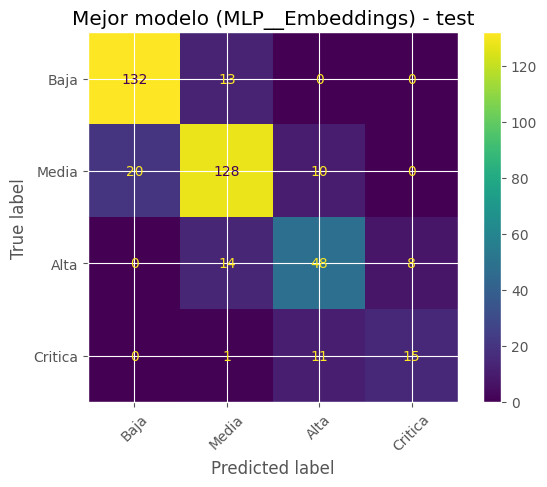

In [24]:
# Recuperamos el run de refit del mejor modelo (su pipeline ya entrenada con train+val).
mejor_refit = runs[(runs["tags.stage"] == "refit_final") & (runs["tags.study_name"] == mejor["study_name"])].iloc[0]
mejor_modelo = mlflow.sklearn.load_model(f"runs:/{mejor_refit['run_id']}/model")

# Evaluación FINAL en test del modelo elegido.
pred_test = mejor_modelo.predict(X_test)
print("Macro recall (test):", round(recall_score(y_test, pred_test, average="macro"), 3))
print(classification_report(y_test, pred_test))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=ORDEN_CLASES, xticks_rotation=45)
plt.title(f"Mejor modelo ({mejor['study_name']}) - test")
plt.show()

Guarda ahora el modelo para utilizarlo en la siguiente fase

In [25]:
import cloudpickle

# El pipeline elegido contiene un tokenizador propio (y se cargó "por valor" desde MLflow),
# así que lo serializamos con cloudpickle para que el artefacto quede autocontenido y portable.
with open("modelo_final.pkl", "wb") as f:
    cloudpickle.dump(mejor_modelo, f)

with mlflow.start_run(run_name=f"modelo_final_{mejor['study_name']}"):
    mlflow.set_tag("stage", "modelo_final")
    mlflow.log_param("modelo_elegido", mejor["study_name"])
    mlflow.log_metric("macro_recall_test", float(recall_score(y_test, pred_test, average="macro")))
    # cloudpickle evita el serializador estricto (skops) que rechaza el tokenizador propio
    mlflow.sklearn.log_model(mejor_modelo, name="modelo_final", serialization_format="cloudpickle")
print("Modelo exportado a modelo_final.pkl")

2026/07/09 09:55:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/07/09 09:55:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Modelo exportado a modelo_final.pkl


Responde:

1. ¿Por qué el conjunto de **test** se lee recién al final y la selección se hace por `macro_recall_val`? **(0.2 pts)**
2. Además de la métrica, ¿qué otros criterios considerarías para elegir el modelo de **producción**? En particular: si el mejor modelo usa **embeddings**, ¿qué implica eso en inferencia (pista: hay que llamar a la API de `gemini-embedding-001`)? **(0.2 pts)**
3. Mira el desempeño **por clase** en test, especialmente `Critica`. ¿El modelo sirve para el objetivo de negocio (priorizar bien los tickets críticos)? **(0.2 pts)**
4. ¿Qué información registrarías en MLflow para que este modelo sea **reproducible y desplegable** por otra persona del equipo? **(0.2 pts)**
5. Mirando todo el barrido, ¿el mejor modelo justifica su complejidad frente a alternativas más simples? ¿Cuál llevarías tú a producción y por qué? **(0.2 pts)**

_Subtotal preguntas: 1.0 pts_

**Responde aquí**

> ...